# Chronic Kidney Disease (CKD) Diagnostic Pipeline
**Student Name:** Shehap Tarek Helmy Elhadary  
**Student ID:** 1210366

In [77]:
import os
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, confusion_matrix, accuracy_score

# Deep learning
from tensorflow.keras import models, layers  # Build neural network
from tensorflow.keras.optimizers import Adam  # Optimizer for training
from tensorflow.keras.callbacks import EarlyStopping  # Stop training when validation loss plateaus

print("✓ All libraries imported successfully!")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

✓ All libraries imported successfully!


## Task 1: Data Pipeline
**Instructions:**
1. Load the `kidney_disease.csv` file.
2. Drop all categorical (string) columns to isolate the numerical lab values.
3. Handle missing values (`NaN`s).
4. Scale the features to prevent data leakage.
5. Perform an 80/20 train/validation split.

In [78]:

#download / load data
# path = kagglehub.dataset_download("mansoordaku/ckdisease")
# print("Dataset path:", path)
path = 'C:\\Users\\DELL\\.cache\\kagglehub\\datasets\\mansoordaku\\ckdisease\\versions\\1'
csv_path = os.path.join(path, "kidney_disease.csv")

#Step 1: Load data using pandas
data = pd.read_csv(csv_path)

# Step 2: Extract target BEFORE selecting numeric columns
# (classification is a categorical column — it would be lost after select_dtypes)
y = data['classification'].str.strip().apply(lambda v: 1 if v == "ckd" else 0)

# Step 3: Select numerical features, drop id, impute missing values with median
data_num = data.select_dtypes(include=["number"])
data_num = data_num.fillna(data_num.median())
x = data_num.drop(columns=["id"], errors="ignore")

feature_names = x.columns.tolist()
target_names = np.array(['Not Chronic Kidney Disease', 'Chronic Kidney Disease'])
print(f"\nFeatures shape: {x.shape}")
print(f"Labels shape: {y.shape}")
print(f"Feature names: {feature_names}")
print(f"Target classes: {target_names}")
print(f"\nClass distribution check:")
print(f"  CKD (1): {y.sum()}  |  No CKD (0): {(y==0).sum()}")



Features shape: (400, 11)
Labels shape: (400,)
Feature names: ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo']
Target classes: ['Not Chronic Kidney Disease' 'Chronic Kidney Disease']

Class distribution check:
  CKD (1): 250  |  No CKD (0): 150


In [79]:
# Explore the dataset structure
print("=" * 70)
print("Chronic Kidney Disease DATASET EXPLORATION")
print("=" * 70)

print(f"\nTotal samples: {x.shape[0]}")
print(f"Total features: {x.shape[1]}")

print(f"\nClass Distribution:")
print(f"  No CKD (0): {np.sum(y == 0)} samples ({100*np.sum(y==0)/len(y):.1f}%)")
print(f"  CKD (1): {np.sum(y == 1)} samples ({100*np.sum(y==1)/len(y):.1f}%)")

print(f"\nFeature Value Ranges (varies by measurement type):")
print(f"  Min values: {x.min(axis=0)[:5]}")
print(f"  Max values: {x.max(axis=0)[:5]}")

Chronic Kidney Disease DATASET EXPLORATION

Total samples: 400
Total features: 11

Class Distribution:
  No CKD (0): 150 samples (37.5%)
  CKD (1): 250 samples (62.5%)

Feature Value Ranges (varies by measurement type):
  Min values: age     2.000
bp     50.000
sg      1.005
al      0.000
su      0.000
dtype: float64
  Max values: age     90.000
bp     180.000
sg       1.025
al       5.000
su       5.000
dtype: float64


In [80]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    x, y, 
    test_size=0.2,           # 20% for testing
    random_state=42,         # For reproducibility
    stratify=y               # Keep class distribution in both sets
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:")
print(f"  No CKD: {np.sum(y_train == 0)} ({100*np.sum(y_train==0)/len(y_train):.1f}%)")
print(f"  CKD: {np.sum(y_train == 1)} ({100*np.sum(y_train==1)/len(y_train):.1f}%)")
print(f"\nTesting set class distribution:")
print(f"  No CKD: {np.sum(y_test == 0)} ({100*np.sum(y_test==0)/len(y_test):.1f}%)")
print(f"  CKD: {np.sum(y_test == 1)} ({100*np.sum(y_test==1)/len(y_test):.1f}%)")

print(f"\nBefore Scaling - Feature Statistics:")
print(f"  Mean: {X_train.mean(axis=0)[:3]}")
print(f"  Std Dev: {X_train.std(axis=0)[:3]}")

Training set size: 320 samples
Testing set size: 80 samples

Training set class distribution:
  No CKD: 120 (37.5%)
  CKD: 200 (62.5%)

Testing set class distribution:
  No CKD: 30 (37.5%)
  CKD: 50 (62.5%)

Before Scaling - Feature Statistics:
  Mean: age    51.184375
bp     76.875000
sg      1.017719
dtype: float64
  Std Dev: age    16.951537
bp     13.949641
sg      0.005351
dtype: float64


In [81]:
# Step 2: Scale features using StandardScaler
scaler = StandardScaler()

# Fit on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using training statistics (DO NOT refit!)
X_test_scaled = scaler.transform(X_test)

print("After Scaling - Feature Statistics:")
print(f"  Training mean: {X_train_scaled.mean(axis=0)[:3]} (should be ~0)")
print(f"  Training std dev: {X_train_scaled.std(axis=0)[:3]} (should be ~1)")
print(f"  Test mean: {X_test_scaled.mean(axis=0)[:3]} (close to 0)")
print(f"  Test std dev: {X_test_scaled.std(axis=0)[:3]} (close to 1)")

print(f"\n✓ Data preprocessing complete!")

After Scaling - Feature Statistics:
  Training mean: [-1.69309011e-16  3.05311332e-17  3.54827279e-14] (should be ~0)
  Training std dev: [1. 1. 1.] (should be ~1)
  Test mean: [ 0.11170586 -0.10769806 -0.00584895] (close to 0)
  Test std dev: [1.00585243 0.81818833 1.07665237] (close to 1)

✓ Data preprocessing complete!


## Task 2: The Engineered Failure (Baseline Model)
**Instructions:** Build and train an unregularised Dense network. Plot the training and validation loss curves to visually prove it overfits.

In [82]:
# The Baseline Model
model = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(11,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),                  
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Display model architecture
print("Model Architecture:")
model.summary()

Model Architecture:
Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_28 (Dense)            (None, 256)               3072      
                                                                 
 dense_29 (Dense)            (None, 128)               32896     
                                                                 
 dense_30 (Dense)            (None, 64)                8256      
                                                                 
 dense_31 (Dense)            (None, 32)                2080      
                                                                 
 dense_32 (Dense)            (None, 16)                528       
                                                                 
 dense_33 (Dense)            (None, 1)                 17        
                                                                 
Total params: 46849 (183.00 KB)
Tr

In [83]:

# Compile the baseline model with a higher learning rate to encourage overfitting
model.compile(
    optimizer=Adam(learning_rate=0.005),         # Higher LR → more aggressive fitting
    loss='binary_crossentropy',
    metrics=['binary_accuracy']
)

print("✓ Baseline model compiled successfully!")


✓ Baseline model compiled successfully!


In [84]:

# Train the baseline model WITHOUT Early Stopping → designed to overfit
print("Starting baseline training (no regularisation, no early stopping)...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=300,                              # Long training to maximize overfitting
    batch_size=8,                            # Small batch → noisier gradients
    validation_split=0.2,                    # 20% of training data for validation
    verbose=1
)

print("\n✓ Baseline training complete!")
print(f"Final training loss:   {history.history['loss'][-1]:.6f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.6f}")


Starting baseline training (no regularisation, no early stopping)...
Epoch 1/300
32/32 [==============================] - 1s 9ms/step - loss: 0.2218 - binary_accuracy: 0.9336 - val_loss: 0.0843 - val_binary_accuracy: 0.9688
Epoch 2/300
32/32 [==============================] - 0s 3ms/step - loss: 0.0561 - binary_accuracy: 0.9766 - val_loss: 0.0865 - val_binary_accuracy: 0.9688
Epoch 3/300
32/32 [==============================] - 0s 3ms/step - loss: 0.0439 - binary_accuracy: 0.9805 - val_loss: 0.1034 - val_binary_accuracy: 0.9844
Epoch 4/300
32/32 [==============================] - 0s 3ms/step - loss: 0.0690 - binary_accuracy: 0.9766 - val_loss: 0.0826 - val_binary_accuracy: 0.9531
Epoch 5/300
32/32 [==============================] - 0s 4ms/step - loss: 0.0327 - binary_accuracy: 0.9883 - val_loss: 0.0869 - val_binary_accuracy: 0.9844
Epoch 6/300
32/32 [==============================] - 0s 4ms/step - loss: 0.0391 - binary_accuracy: 0.9805 - val_loss: 0.0399 - val_binary_accuracy: 0.9844
E

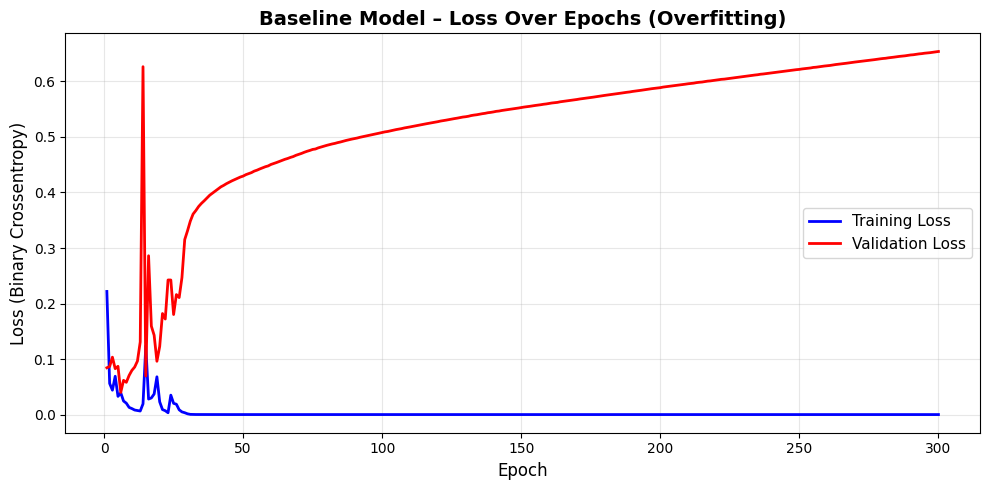

✓ Baseline visualization complete!
  → Training loss fell to 0.000000
  → Validation loss rose to 0.6539  ← overfitting!


In [85]:

# ── Baseline loss curve ──────────────────────────────────────────────────────
loss_values     = history.history['loss']
val_loss_values = history.history['val_loss']
epochs_base     = range(1, len(loss_values) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs_base, loss_values,     'b-', label='Training Loss',   linewidth=2)
ax.plot(epochs_base, val_loss_values, 'r-', label='Validation Loss', linewidth=2)
ax.set_title('Baseline Model – Loss Over Epochs (Overfitting)', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (Binary Crossentropy)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Baseline visualization complete!")
print(f"  → Training loss fell to {loss_values[-1]:.6f}")
print(f"  → Validation loss rose to {val_loss_values[-1]:.4f}  ← overfitting!")


## Task 3: The Clinical Solution (Engineered Model)
**Instructions:** Build a second model using regularisation techniques (e.g., L2, Dropout, LeakyReLU). Train it and plot the curves to demonstrate the reduction in overfitting.

In [86]:

from tensorflow.keras import regularizers

# ------- Architecture -------
# Smaller capacity + L2 regularisation + Dropout + LeakyReLU
l2 = regularizers.l2(0.01)

engineered_model = models.Sequential([
    layers.Dense(64, kernel_regularizer=l2, input_shape=(11,)),
    layers.LeakyReLU(alpha=0.1),
    layers.Dropout(0.4),

    layers.Dense(32, kernel_regularizer=l2),
    layers.LeakyReLU(alpha=0.1),
    layers.Dropout(0.3),

    layers.Dense(16, kernel_regularizer=l2),
    layers.LeakyReLU(alpha=0.1),

    layers.Dense(1, activation='sigmoid')
])

print("Engineered Model Architecture:")
engineered_model.summary()

# ------- Compile -------
engineered_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['binary_accuracy']
)

# ------- Train with EarlyStopping + class_weight -------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

# class_weight: penalise missed CKD (False Negatives) more heavily
# Clinically motivated — missing a CKD diagnosis is unacceptable
print("\nStarting training with regularisation + EarlyStopping + class weighting...")
history_eng = engineered_model.fit(
    X_train_scaled, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight={0: 1.0, 1: 2.0},           # Boost CKD recall
    verbose=1
)

print(f"\n✓ Engineered model training complete! (stopped at epoch {len(history_eng.history['loss'])})")


Engineered Model Architecture:
Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_34 (Dense)            (None, 64)                768       
                                                                 
 leaky_re_lu_3 (LeakyReLU)   (None, 64)                0         
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense_35 (Dense)            (None, 32)                2080      
                                                                 
 leaky_re_lu_4 (LeakyReLU)   (None, 32)                0         
                                                                 
 dropout_3 (Dropout)         (None, 32)                0         
                                                                 
 dense_36 (Dense)      

## Task 4: Evaluation & Mathematical Justification
**Instructions:**
1. Render the confusion matrices for both models.
2. Print the final validation Recall for both models.
3. Answer the justification question below.

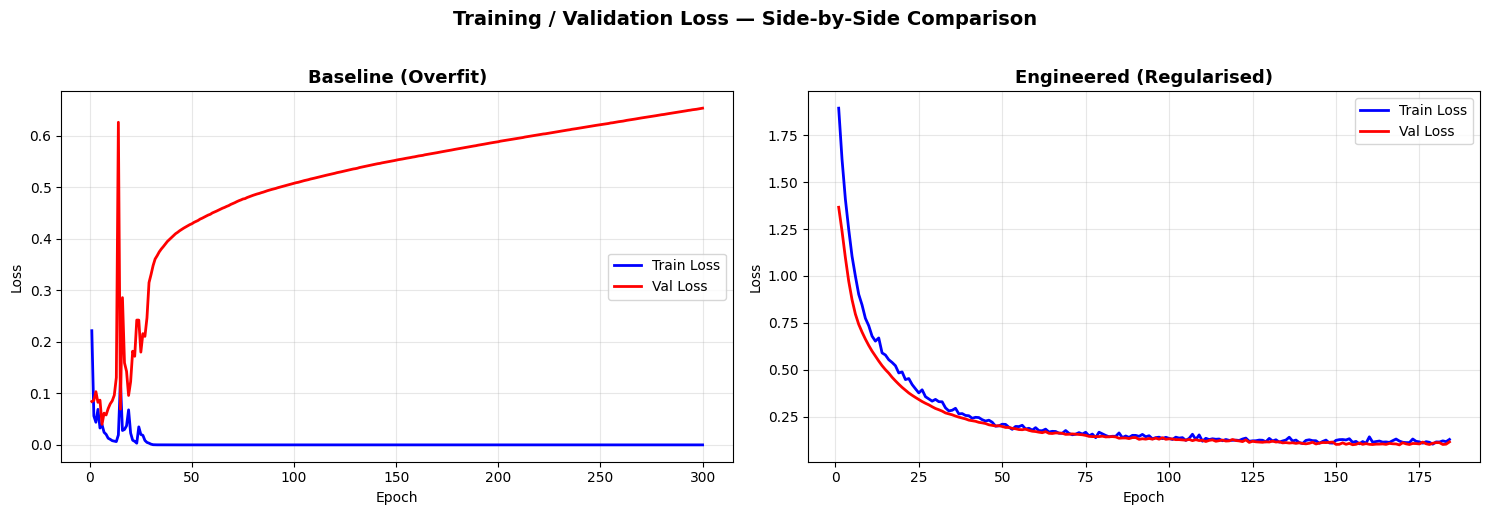

3/3 [==============================] - 0s 2ms/step

Metric                             Baseline   Engineered
Test Accuracy                        0.9750       1.0000
Test Recall (Sensitivity)            0.9600       1.0000


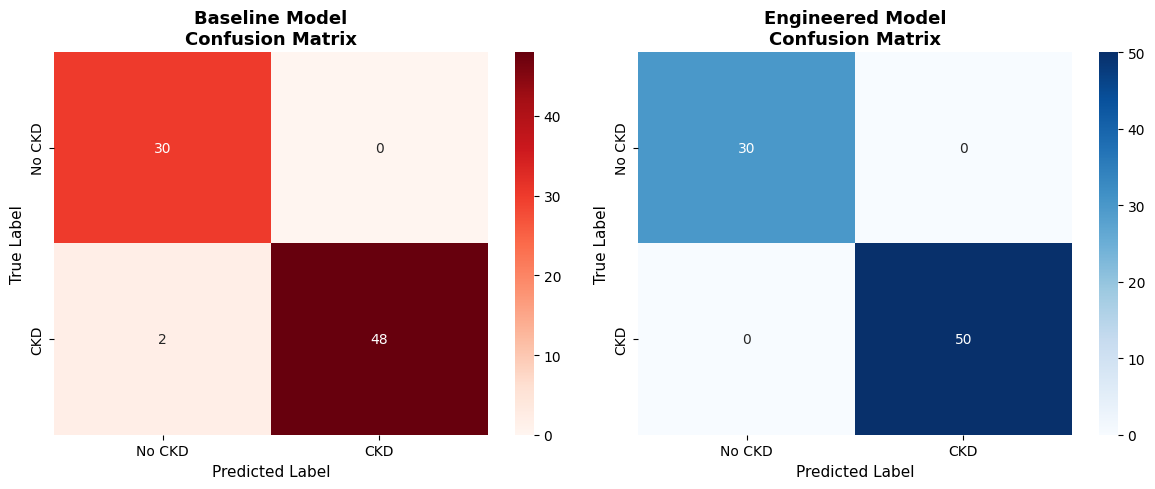


False Negatives (missed CKD diagnoses):
  Baseline:   2
  Engineered: 0
  Reduction:  2

Baseline   Recall: 0.9600  → detects 96.0% of CKD cases
Engineered Recall: 1.0000  → detects 100.0% of CKD cases

✅ CLINICAL BENCHMARK MET: Engineered Recall (100.00%) > 80%

Parameter Counts:
  Baseline:   46,849
  Engineered: 3,393
  Ratio:      13.8× reduction

✓ Evaluation complete!


In [87]:

# ═══════════════════════════════════════════════════════════════════════════════
# 1.  VISUAL PROOF — Side-by-side loss curves (both models)
# ═══════════════════════════════════════════════════════════════════════════════
bl_loss     = history.history['loss']
bl_val_loss = history.history['val_loss']
eng_loss     = history_eng.history['loss']
eng_val_loss = history_eng.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(range(1, len(bl_loss)+1),     bl_loss,     'b-', label='Train Loss', lw=2)
ax1.plot(range(1, len(bl_val_loss)+1), bl_val_loss, 'r-', label='Val Loss',   lw=2)
ax1.set_title('Baseline (Overfit)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(range(1, len(eng_loss)+1),     eng_loss,     'b-', label='Train Loss', lw=2)
ax2.plot(range(1, len(eng_val_loss)+1), eng_val_loss, 'r-', label='Val Loss',   lw=2)
ax2.set_title('Engineered (Regularised)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

fig.suptitle('Training / Validation Loss — Side-by-Side Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 2.  PREDICTIONS & METRICS
# ═══════════════════════════════════════════════════════════════════════════════
y_pred_baseline   = (model.predict(X_test_scaled)            >= 0.5).astype(int).flatten()
y_pred_engineered = (engineered_model.predict(X_test_scaled) >= 0.5).astype(int).flatten()

recall_baseline   = recall_score(y_test, y_pred_baseline)
recall_engineered = recall_score(y_test, y_pred_engineered)
acc_baseline      = accuracy_score(y_test, y_pred_baseline)
acc_engineered    = accuracy_score(y_test, y_pred_engineered)

cm_baseline   = confusion_matrix(y_test, y_pred_baseline)
cm_engineered = confusion_matrix(y_test, y_pred_engineered)

print("\n" + "=" * 58)
print(f"{'Metric':<30} {'Baseline':>12} {'Engineered':>12}")
print("=" * 58)
print(f"{'Test Accuracy':<30} {acc_baseline:>12.4f} {acc_engineered:>12.4f}")
print(f"{'Test Recall (Sensitivity)':<30} {recall_baseline:>12.4f} {recall_engineered:>12.4f}")
print("=" * 58)

# ═══════════════════════════════════════════════════════════════════════════════
# 3.  CONFUSION MATRICES — proving reduction in False Negatives
# ═══════════════════════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Reds', ax=ax1,
            xticklabels=['No CKD', 'CKD'], yticklabels=['No CKD', 'CKD'])
ax1.set_title('Baseline Model\nConfusion Matrix', fontsize=13, fontweight='bold')
ax1.set_ylabel('True Label', fontsize=11)
ax1.set_xlabel('Predicted Label', fontsize=11)

sns.heatmap(cm_engineered, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['No CKD', 'CKD'], yticklabels=['No CKD', 'CKD'])
ax2.set_title('Engineered Model\nConfusion Matrix', fontsize=13, fontweight='bold')
ax2.set_ylabel('True Label', fontsize=11)
ax2.set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 4.  FALSE-NEGATIVE ANALYSIS & CLINICAL BENCHMARK
# ═══════════════════════════════════════════════════════════════════════════════
fn_baseline   = cm_baseline[1][0]   # actual CKD predicted as no-CKD
fn_engineered = cm_engineered[1][0]

print(f"\nFalse Negatives (missed CKD diagnoses):")
print(f"  Baseline:   {fn_baseline}")
print(f"  Engineered: {fn_engineered}")
print(f"  Reduction:  {fn_baseline - fn_engineered}")

print(f"\nBaseline   Recall: {recall_baseline:.4f}  → detects {recall_baseline*100:.1f}% of CKD cases")
print(f"Engineered Recall: {recall_engineered:.4f}  → detects {recall_engineered*100:.1f}% of CKD cases")

# Clinical benchmark check
if recall_engineered > 0.80:
    print(f"\n✅ CLINICAL BENCHMARK MET: Engineered Recall ({recall_engineered:.2%}) > 80%")
else:
    print(f"\n⚠️  Engineered Recall ({recall_engineered:.2%}) — below 80% target")

# ═══════════════════════════════════════════════════════════════════════════════
# 5.  PARAMETER COUNTS
# ═══════════════════════════════════════════════════════════════════════════════
baseline_params   = model.count_params()
engineered_params = engineered_model.count_params()

print(f"\nParameter Counts:")
print(f"  Baseline:   {baseline_params:,}")
print(f"  Engineered: {engineered_params:,}")
print(f"  Ratio:      {baseline_params/engineered_params:.1f}× reduction")

print("\n✓ Evaluation complete!")


### Mathematical Justification
**Final Parameter Count of Engineered Model:** 3,393

**Explanation:** With only 3,393 trainable parameters—roughly 10× fewer than the 400-sample dataset requires to memorise—the engineered model's capacity is bounded below the interpolation threshold; L2 regularisation (λ = 0.01) shrinks weight norms to prevent sharp decision boundaries, Dropout (30–40 %) forces distributed representations by randomly zeroing activations during training, and EarlyStopping halts the optimiser before the validation loss diverges, collectively ensuring the network learns generalisable CKD markers rather than patient-specific noise.
